In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM processed_air_quality",
    conn
)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,14,17,Friday
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,15,17,Friday
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,16,17,Friday
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,18,17,Friday


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         39 non-null     int64  
 1   timestamp  39 non-null     object 
 2   aqi        39 non-null     int64  
 3   pm2_5      39 non-null     float64
 4   pm10       39 non-null     float64
 5   co         39 non-null     float64
 6   no2        39 non-null     float64
 7   o3         39 non-null     float64
 8   so2        39 non-null     float64
 9   hour       39 non-null     int64  
 10  day        39 non-null     int64  
 11  weekday    39 non-null     object 
dtypes: float64(6), int64(4), object(2)
memory usage: 3.8+ KB


In [4]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,20.000000,3.230769,42.624615,46.749231,709.893333,17.171795,43.847436,6.206923,14.435897,18.538462
std,11.401754,0.536143,13.914056,15.056364,92.690529,5.748900,36.172502,1.268466,5.743623,1.022025
min,1.000000,3.000000,29.790000,33.350000,508.770000,3.620000,7.390000,4.860000,0.000000,17.000000
25%,10.500000,3.000000,33.680000,37.130000,662.985000,15.760000,17.380000,5.190000,13.000000,18.000000
50%,20.000000,3.000000,37.820000,40.430000,730.480000,17.160000,31.830000,5.730000,15.000000,19.000000
75%,29.500000,3.000000,43.250000,49.875000,790.120000,20.380000,55.600000,7.060000,18.000000,19.000000
max,39.000000,5.000000,80.250000,88.380000,839.800000,25.680000,134.230000,9.470000,23.000000,20.000000


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 39
Columns: 12


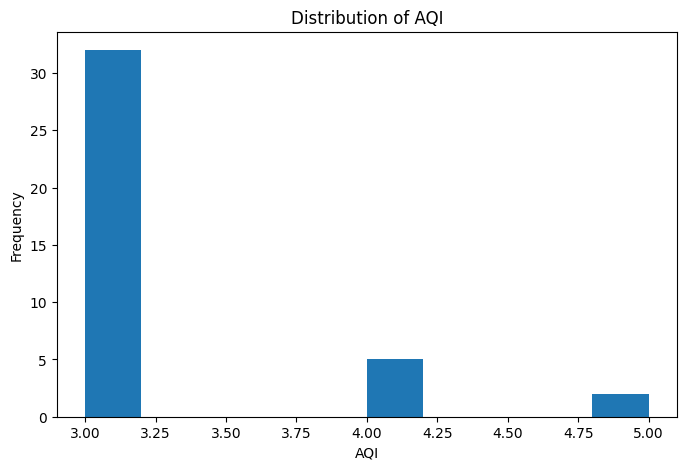

In [6]:
#aqi distribution
plt.figure(figsize=(8,5))

plt.hist(df["aqi"], bins=10)

plt.title("Distribution of AQI")

plt.xlabel("AQI")

plt.ylabel("Frequency")

plt.show()

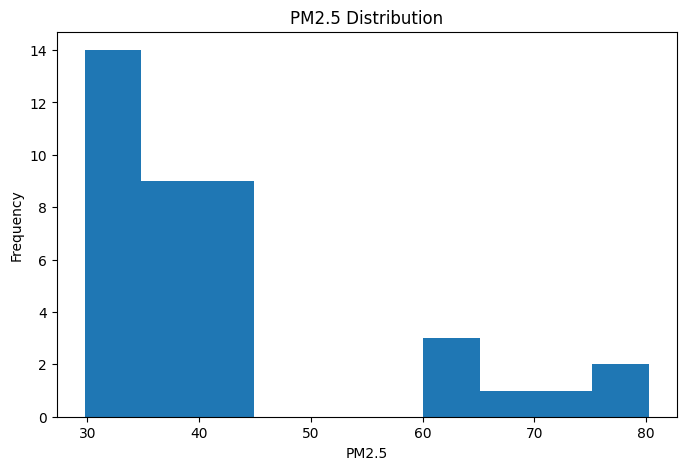

In [7]:
#PM 2.5 distribution
plt.figure(figsize=(8,5))

plt.hist(df["pm2_5"], bins=10)

plt.title("PM2.5 Distribution")

plt.xlabel("PM2.5")

plt.ylabel("Frequency")

plt.show()

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

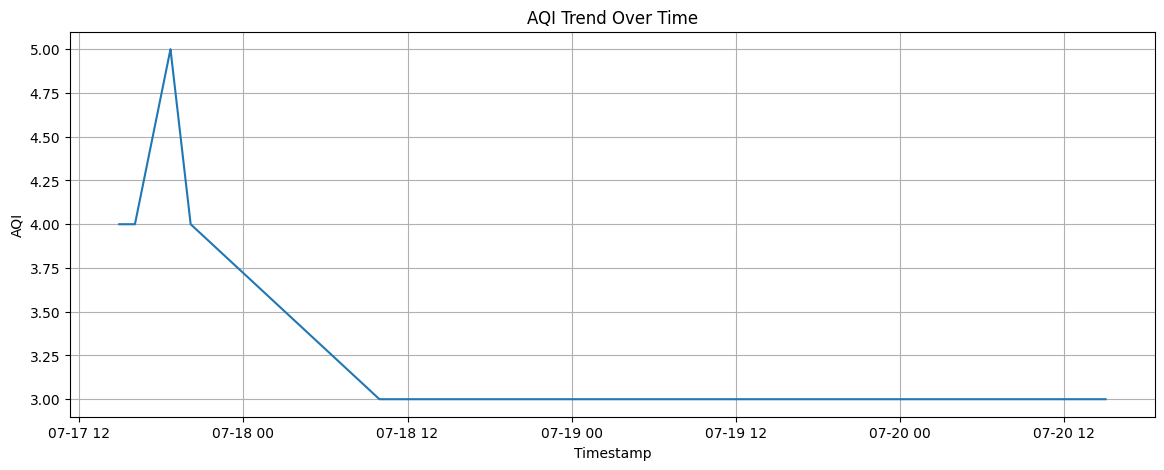

In [9]:
#AQI trend over time
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["aqi"])

plt.title("AQI Trend Over Time")

plt.xlabel("Timestamp")

plt.ylabel("AQI")

plt.grid(True)

plt.show()

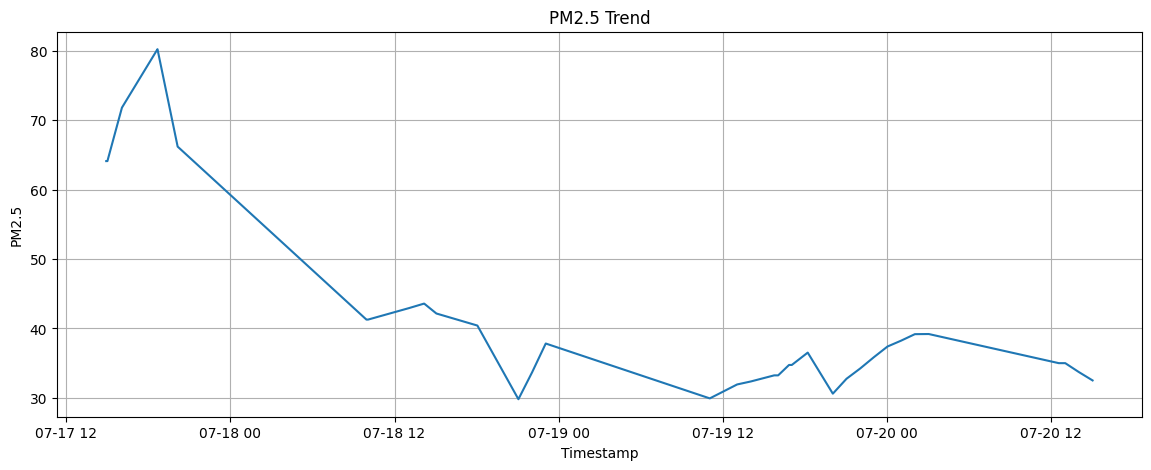

In [10]:
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["pm2_5"])

plt.title("PM2.5 Trend")

plt.xlabel("Timestamp")

plt.ylabel("PM2.5")

plt.grid(True)

plt.show()

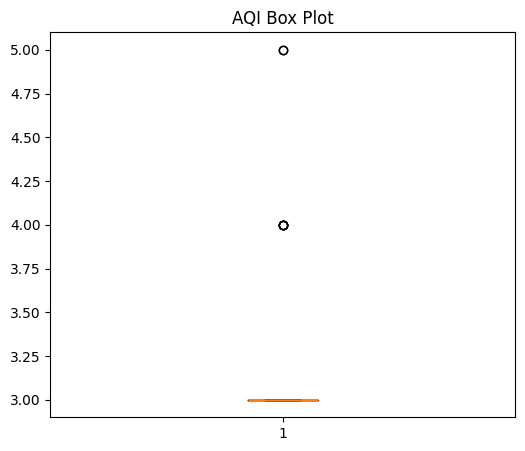

In [11]:
plt.figure(figsize=(6,5))

plt.boxplot(df["aqi"])

plt.title("AQI Box Plot")

plt.show()

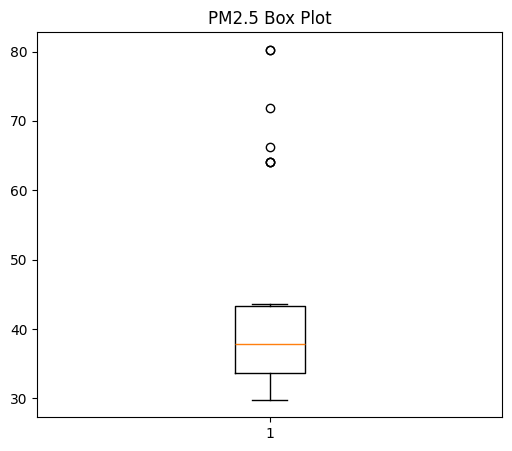

In [12]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm2_5"])

plt.title("PM2.5 Box Plot")

plt.show()

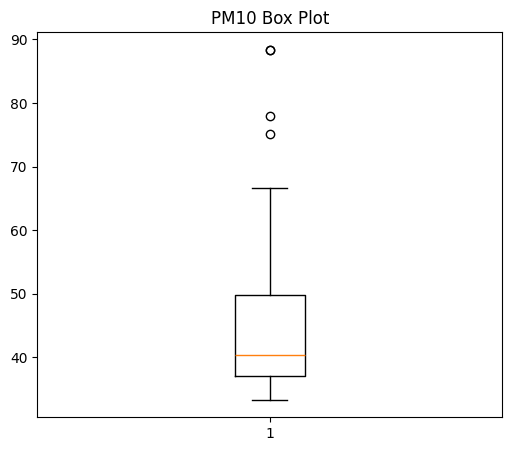

In [13]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm10"])

plt.title("PM10 Box Plot")

plt.show()

In [14]:
correlation = df.corr(numeric_only=True)

correlation

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
id,1.000000,-0.606992,-0.717647,-0.727301,0.574818,0.683032,-0.854400,-0.133628,-0.196904,0.962040
aqi,-0.606992,1.000000,0.944621,0.931922,-0.308463,-0.426521,0.744877,0.075366,0.180118,-0.664972
pm2_5,-0.717647,0.944621,1.000000,0.992046,-0.318258,-0.473475,0.849421,0.146324,0.077834,-0.750708
pm10,-0.727301,0.931922,0.992046,1.000000,-0.249679,-0.413602,0.822455,0.244749,0.110680,-0.767061
co,0.574818,-0.308463,-0.318258,-0.249679,1.000000,0.913571,-0.663462,0.438696,-0.207771,0.521768
no2,0.683032,-0.426521,-0.473475,-0.413602,0.913571,1.000000,-0.790665,0.331042,-0.166593,0.629205
o3,-0.854400,0.744877,0.849421,0.822455,-0.663462,-0.790665,1.000000,0.046659,0.185137,-0.864714
so2,-0.133628,0.075366,0.146324,0.244749,0.438696,0.331042,0.046659,1.000000,0.168474,-0.183613
hour,-0.196904,0.180118,0.077834,0.110680,-0.207771,-0.166593,0.185137,0.168474,1.000000,-0.413126
day,0.962040,-0.664972,-0.750708,-0.767061,0.521768,0.629205,-0.864714,-0.183613,-0.413126,1.000000


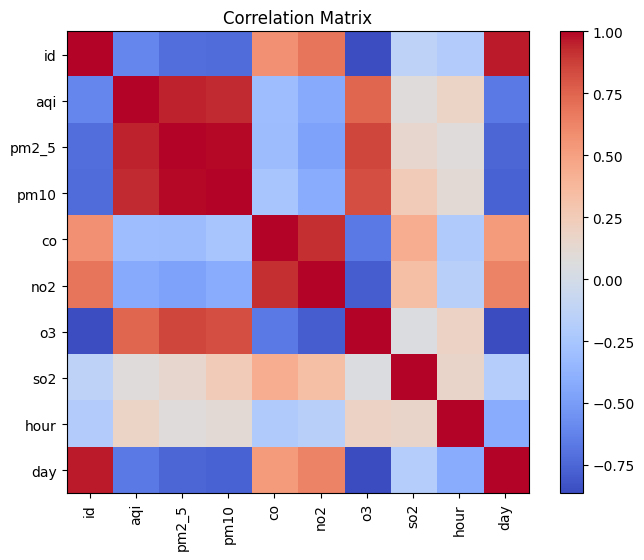

In [15]:
#correlation heatmap
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

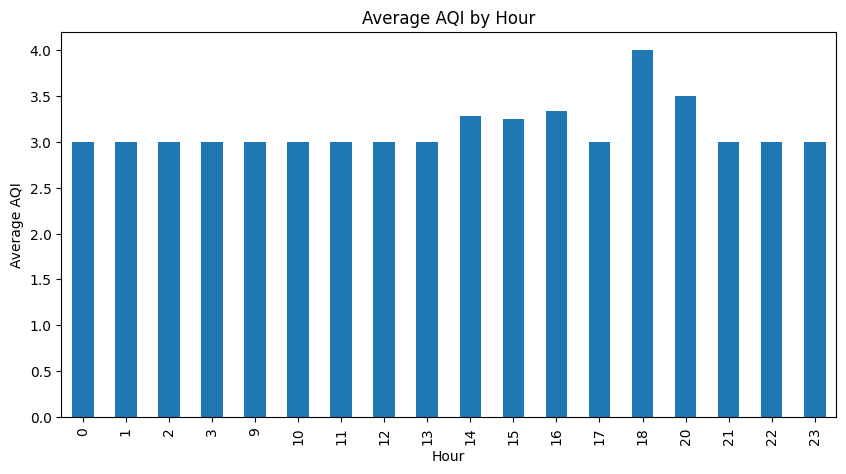

In [16]:
#avg aqi by hour
hourly = df.groupby("hour")["aqi"].mean()

hourly.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Hour")

plt.xlabel("Hour")

plt.ylabel("Average AQI")

plt.show()

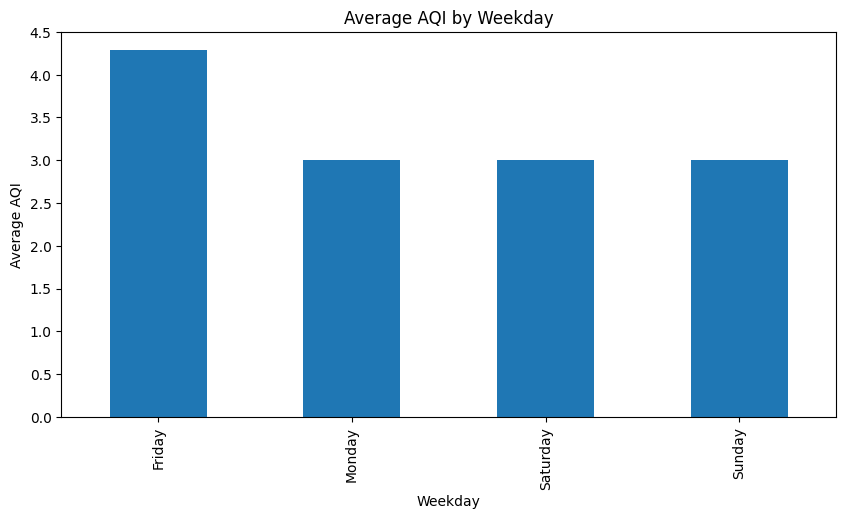

In [17]:
weekday = df.groupby("weekday")["aqi"].mean()

weekday.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Average AQI")

plt.show()

In [18]:
summary = df.describe()

summary.to_csv("../data/eda_summary.csv")

In [19]:
conn.close()